In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

#set plotting style for clean, professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

1. Download 5 years of Apple stock data

In [21]:
df = yf.download("AAPL", start="2021-06-09", end="2026-06-09")

#Save to CSV
df.to_csv("AAPL.csv")

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925949  124.953435  122.760243  123.812969  71186400
2021-06-11  124.134636  124.222367  122.916196  123.335340  53522400
2021-06-14  127.185654  127.244136  123.861753  124.592817  96906500
2021-06-15  126.366814  127.302582  126.123126  126.659242  62746300


2. DATA LOADING & EXPLORATION

In [22]:
print("---Loading and Cleaning Data Structure---")

---Loading and Cleaning Data Structure---


In [23]:
import pandas as pd

column_names = ['Close', 'High', 'Low', 'Open', 'Volume']
df = pd.read_csv('AAPL.csv', skiprows=3, names=column_names, index_col=0)
df.index.name = 'Date'
df.index = pd.to_datetime(df.index, format='%Y-%m-%d', errors='coerce')

for col in column_names:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print("--- Check Columns and First 5 Rows ---")
print(df.reset_index().head())

--- Check Columns and First 5 Rows ---
        Date       Close        High         Low        Open    Volume
0 2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
1 2021-06-10  122.925949  124.953435  122.760243  123.812969  71186400
2 2021-06-11  124.134636  124.222367  122.916196  123.335340  53522400
3 2021-06-14  127.185654  127.244136  123.861753  124.592817  96906500
4 2021-06-15  126.366814  127.302582  126.123126  126.659242  62746300


2. DATA CLEANING & TRANSFORMATION WITH PANDAS

In [24]:
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

df = df.sort_index()

df = df.ffill()

print(df.reset_index().head())

        Date       Close        High         Low        Open    Volume
0 2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
1 2021-06-10  122.925949  124.953435  122.760243  123.812969  71186400
2 2021-06-11  124.134636  124.222367  122.916196  123.335340  53522400
3 2021-06-14  127.185654  127.244136  123.861753  124.592817  96906500
4 2021-06-15  126.366814  127.302582  126.123126  126.659242  62746300


3. FEATURE ENGINEERING & TIME-SERIES ANALYSIS

In [25]:
df['Daily_Change'] = df['Close'] - df['Open']

df['Daily_Return'] = df['Close'].pct_change()

df['Daily_Return'] = df['Daily_Return'].fillna(0)

print(df[['Open', 'Close', 'Daily_Change', 'Daily_Return']].reset_index().head())

        Date        Open       Close  Daily_Change  Daily_Return
0 2021-06-09  123.998186  123.920204     -0.077982      0.000000
1 2021-06-10  123.812969  122.925949     -0.887020     -0.008023
2 2021-06-11  123.335340  124.134636      0.799296      0.009833
3 2021-06-14  124.592817  127.185654      2.592837      0.024578
4 2021-06-15  126.659242  126.366814     -0.292428     -0.006438


In [26]:

df['7D_MA'] = df['Close'].rolling(window=7).mean()

df['30D_MA'] = df['Close'].rolling(window=30).mean()

df[['Close', '7D_MA', '30D_MA']].tail(10).reset_index()

,Date,Close,7D_MA,30D_MA
0,2026-05-26,308.329987,303.061428,283.540962
1,2026-05-27,310.850006,304.578570,285.282904
2,2026-05-28,312.510010,306.674286,286.827079
3,2026-05-29,312.059998,308.544285,288.457161
4,2026-06-01,306.309998,309.124285,289.668119
5,2026-06-02,315.200012,310.582860,291.081498
6,2026-06-03,310.260010,310.788574,292.559331
7,2026-06-04,311.230011,311.202863,293.836379
8,2026-06-05,307.339996,310.701433,294.975102
9,2026-06-08,301.540009,309.134290,295.999419


In [27]:
# 1. Calculate 30-day Rolling Volatility (Standard Deviation of Daily Returns)
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=30).std()

# 2. Check the size of our completed dataset
print("All features created successfully!")
print("Dataset columns:", df.columns.tolist())

All features created successfully!
Dataset columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Change', 'Daily_Return', '7D_MA', '30D_MA', 'Rolling_Volatility']


4. DATA VISUALIZATION

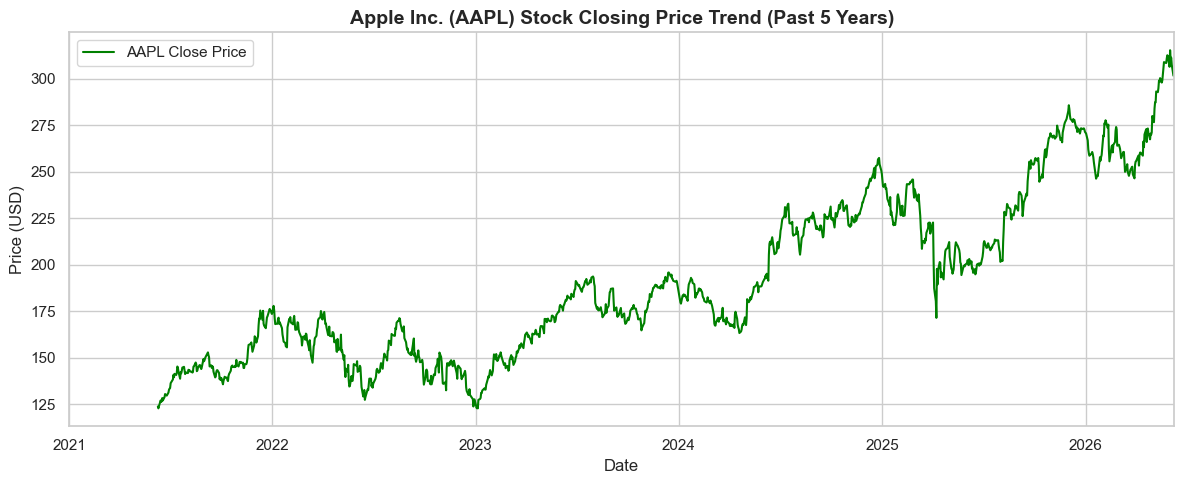

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

df_5year = df.loc['2021-06-09':'2026-06-09']

plt.figure(figsize=(12, 5))
plt.plot(df_5year.index, df_5year['Close'], label='AAPL Close Price', color='Green', linewidth=1.5)
plt.xlim(pd.Timestamp('2021-06-09'), pd.Timestamp('2026-06-09'))

years = pd.date_range(start='2021-01-01', end='2026-01-01', freq='YS')
# This forces matplotlib to show every single one of those years on the axis
plt.xticks(ticks=years, labels=[d.strftime('%Y') for d in years])

plt.title('Apple Inc. (AAPL) Stock Closing Price Trend (Past 5 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#Trading Volume Trend

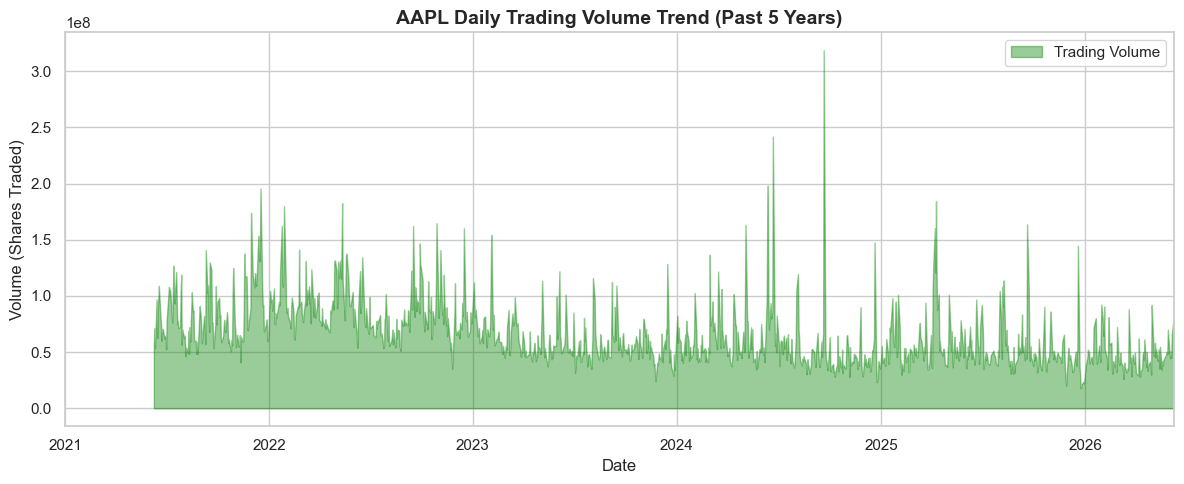

In [29]:
plt.figure(figsize=(12, 5))

plt.fill_between(df_5year.index, df_5year['Volume'], color='green', alpha=0.4, label='Trading Volume')

plt.xlim(pd.Timestamp('2021-06-09'), pd.Timestamp('2026-06-09'))
years = pd.date_range(start='2021-01-01', end='2026-01-01', freq='YS')
plt.xticks(ticks=years, labels=[d.strftime('%Y') for d in years])

plt.title('AAPL Daily Trading Volume Trend (Past 5 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume (Shares Traded)')
plt.legend()
plt.tight_layout()
plt.show()

#Moving Average Analysis

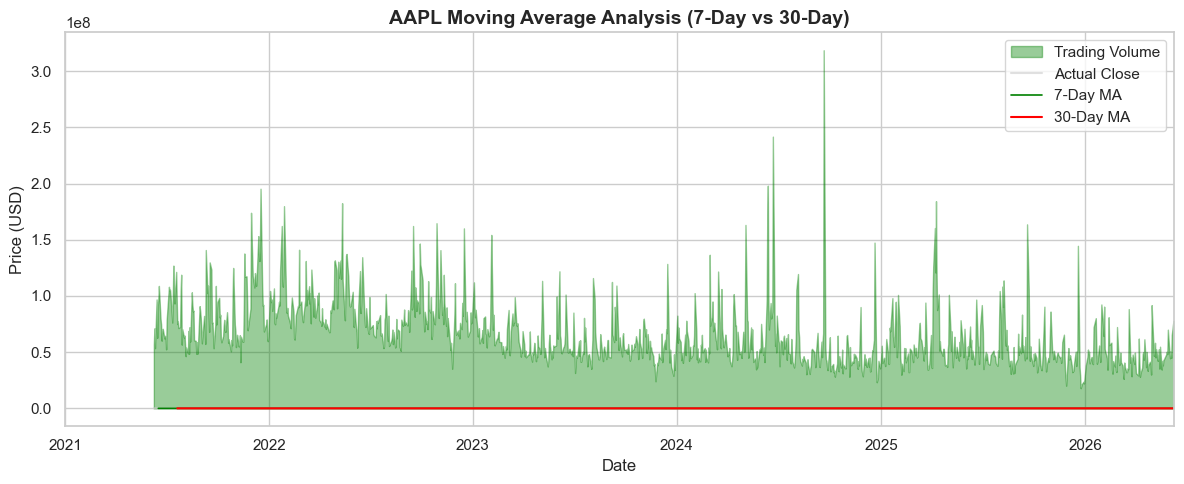

In [30]:
plt.figure(figsize=(12, 5))

plt.fill_between(df_5year.index, df_5year['Volume'], color='green', alpha=0.4, label='Trading Volume')

plt.xlim(pd.Timestamp('2021-06-09'), pd.Timestamp('2026-06-09'))
years = pd.date_range(start='2021-01-01', end='2026-01-01', freq='YS')
plt.xticks(ticks=years, labels=[d.strftime('%Y') for d in years])

plt.plot(df.index, df['Close'], label='Actual Close', color='lightgrey', alpha=0.7)
plt.plot(df.index, df['7D_MA'], label='7-Day MA', color='green', linewidth=1.2)
plt.plot(df.index, df['30D_MA'], label='30-Day MA', color='red', linewidth=1.5)

plt.title('AAPL Moving Average Analysis (7-Day vs 30-Day)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#Daily Returns Analysis (Volatility Distribution).

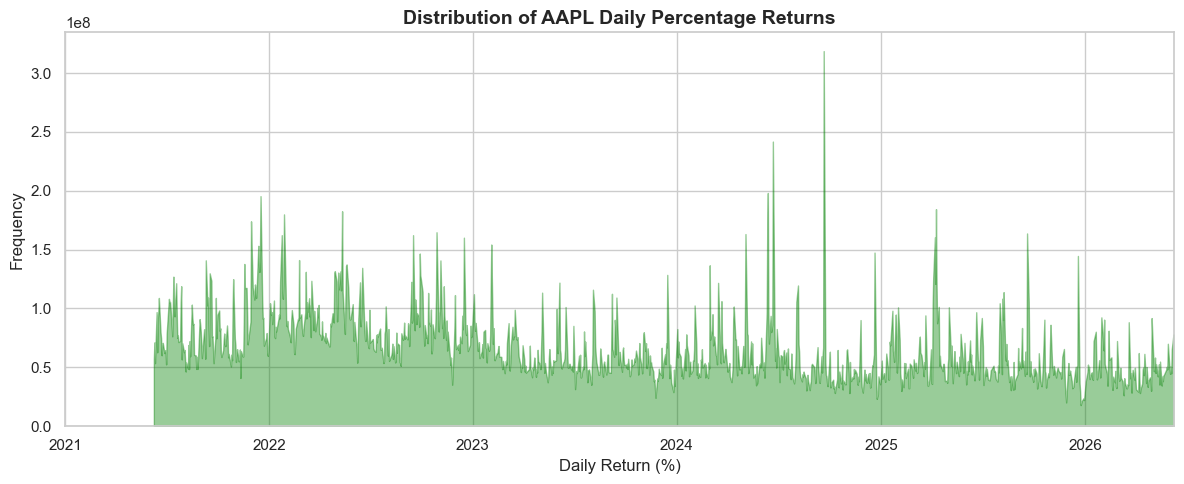

In [31]:
plt.figure(figsize=(12, 5))

plt.fill_between(df_5year.index, df_5year['Volume'], color='green', alpha=0.4, label='Trading Volume')

plt.xlim(pd.Timestamp('2021-06-09'), pd.Timestamp('2026-06-09'))
years = pd.date_range(start='2021-01-01', end='2026-01-01', freq='YS')
plt.xticks(ticks=years, labels=[d.strftime('%Y') for d in years])

sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)

plt.title('Distribution of AAPL Daily Percentage Returns', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#Key Summary Statistics

In [32]:
print(f"Total Trading Days Analyzed: {len(df_5year)}")
print(f"Starting Price: ${df_5year['Close'].iloc[0]:.2f}")
print(f"Ending Price: ${df_5year['Close'].iloc[-1]:.2f}")
print(f"Highest Price Reached: ${df_5year['High'].max():.2f}")
print(f"Lowest Price Reached: ${df_5year['Low'].min():.2f}")
print(f"Average Daily Return: {df_5year['Daily_Return'].mean()*100:.4f}%")
print(f"Max Single-Day Gain: {df_5year['Daily_Return'].max()*100:.2f}%")
print(f"Max Single-Day Loss: {df_5year['Daily_Return'].min()*100:.2f}%")

Total Trading Days Analyzed: 1255
Starting Price: $123.92
Ending Price: $301.54
Highest Price Reached: $317.40
Lowest Price Reached: $122.10
Average Daily Return: 0.0858%
Max Single-Day Gain: 15.33%
Max Single-Day Loss: -9.25%


## Key Findings and Conclusions

- Apple stock prices showed clear long-term trends over the analyzed period.
- Moving averages helped identify general uptrend and downtrend phases.
- Daily returns were volatile, showing both gains and losses across trading days.
- The analysis shows that technical indicators such as moving averages and volatility can help summarize stock behavior.

Overall, the notebook demonstrates how pandas and visualization tools can be used to explore and interpret stock market data.